In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('daily-total-female-births.csv', index_col="Date")
df.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


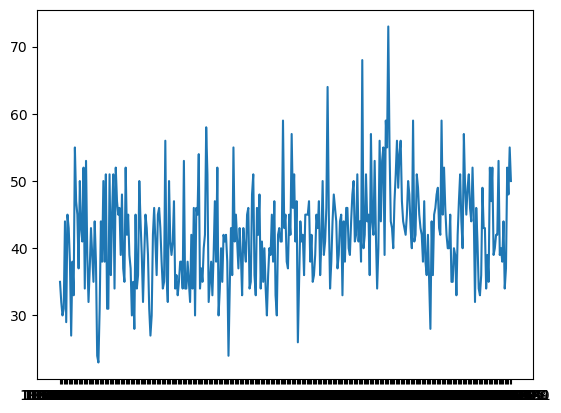

In [81]:
plt.plot(df)

### Sequence forecasting

In [ ]:
def timeseries_to_supervised(data, n_in=1, n_out=1, del_nan=True):
    data = pd.DataFrame(data)
    cols = list()
    for i in range(n_in, 0, -1):
        cols.append(data.shift(i))    
    for i in range(0, n_out):
        cols.append(data.shift(-i))    
    output = pd.concat(cols, axis=1)
    if del_nan:
        output.dropna(inplace=True)
    
    return output.values


In [83]:
def train_test_split(data, num_of_pred):
    train = data[:-num_of_pred, :]
    test = data[-num_of_pred:, :]
    return train, test

### Random Forest Regression

In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def randomforest_prediction(train, test):
    train = np.asarray(train)
    train_X = train[:, :-1]
    test_y = train[:, -1]

    rf_model = RandomForestRegressor(n_estimators=1000)
    rf_model.fit(train_X, test_y)

    prediction = rf_model.predict([test])
    return prediction[0]

In [ ]:
# predict last 12 rows using Expanding window algorithm.
def predict_num_of_female_births(data, num_of_pred=12):
    data = np.asarray(data)
    train, test = train_test_split(data, num_of_pred)

    pred_result = list()
    history = [x for x in train]

    for i in range(len(test)):
        test_X, test_y = test[i, :-1], test[i, -1]
        y_hat = randomforest_prediction(history, test_X)
        pred_result.append(y_hat)
        history.append(test[i])
        print("real: %d,  predict: %d" % (test_y, y_hat))
    
    mse = mean_absolute_error(test[:, -1], pred_result)
    return mse, test[:, -1], pred_result

In [92]:
data = timeseries_to_supervised(df, n_in=6)
data

array([[35., 32., 30., ..., 44., 29., 45.],
       [32., 30., 31., ..., 29., 45., 43.],
       [30., 31., 44., ..., 45., 43., 38.],
       ...,
       [40., 38., 44., ..., 37., 52., 48.],
       [38., 44., 34., ..., 52., 48., 55.],
       [44., 34., 37., ..., 48., 55., 50.]])

real: 42,  predict: 45
real: 53,  predict: 43
real: 39,  predict: 41
real: 40,  predict: 38
real: 38,  predict: 43
real: 44,  predict: 48
real: 34,  predict: 42
real: 37,  predict: 37
real: 52,  predict: 38
real: 48,  predict: 41
real: 55,  predict: 43
real: 50,  predict: 45
mse: 5.961749999999999


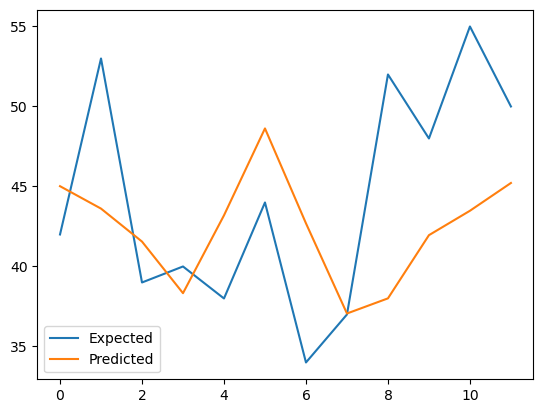

In [ ]:
mae, y, y_hat = predict_num_of_female_births(data, 12)
print('mae:', mae)
plt.plot(y, label='Expected')
plt.plot(y_hat, label='Predicted')
plt.legend()
plt.show()

### predict num of females born on 1960-01-01

In [99]:
next_pred = data[-1, 1:].reshape(1, -1)
next_pred

array([[34., 37., 52., 48., 55., 50.]])

In [104]:
train_X, train_y = data[:, :-1], data[:, -1]
model_rf = RandomForestRegressor(n_estimators=1000)

model_rf.fit(train_X, train_y)
num_pred = model_rf.predict(next_pred)[0]
print('input: %s, predict: %s' % (next_pred[0], num_pred))

input: [34. 37. 52. 48. 55. 50.], predict: 42.877
